# Fourier transforms notebook

## Fourier series

We can express periodic functions in terms of a sum of sine and cosine functions, a Fourier series. 

$$
f(x) = \sum_{k=0}^{\infty}\alpha_k\cos\left(\frac{2\pi k x}{L}\right) + \sum_{k=1}^{\infty}\beta_k\sin\left(\frac{2\pi k x}{L}\right)
$$

The coefficients $\alpha_k$ and $\beta_k$ depend on the function $f(x)$ which is assumed to have a periodicity $L$. 

Consider a step function defined as:

$$
f(x) = 
\begin{cases}
1 & \text{if  } 0 \leq x \leq 0.5 \\
-1 & \text{if  } 0.5 < x \leq 1
\end{cases}
$$

We can calculate the coefficients for this function to be:

$$
\alpha_k = 0
$$

and

$$
\beta_k = 
\begin{cases}
\frac{4}{k\pi} & k \text{ is even} \\
0 & k \text{ is odd}
\end{cases}
$$

I can express this function in both the x and frequency domains.

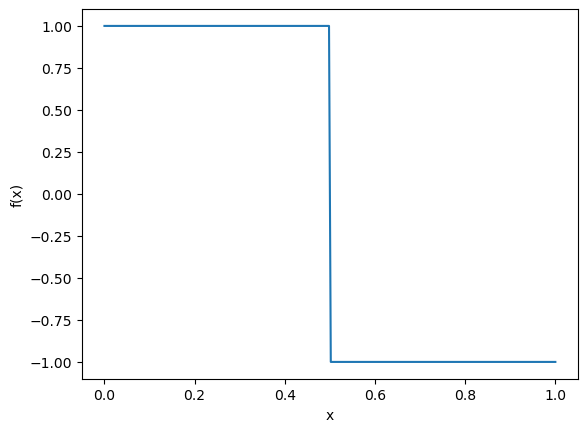

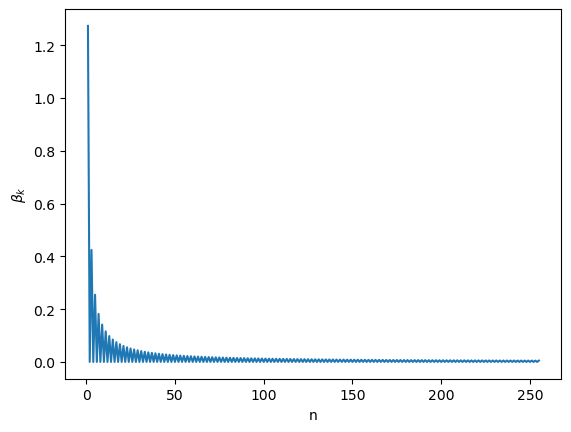

In [29]:
import numpy as np 
import matplotlib.pyplot as plt 

N = 256

x_array = np.linspace(0, 1, num=N)
fx = [1 if x < 0.5 else -1 for x in x_array]

n_array = np.arange(1,N)
beta = [4/n/np.pi if n%2 == 1 else 0 for n in n_array]

fig1 = plt.figure()
ax1 = fig1.add_subplot(111)
ax1.plot(x_array, fx)
ax1.set_ylabel("f(x)")
ax1.set_xlabel("x")

fig2 = plt.figure()
ax2 = fig2.add_subplot(111)
ax2.plot(n_array, beta)
ax2.set_ylabel(r"$\beta_k$")
ax2.set_xlabel("n")

plt.show()

The second graph tells us the amplitude of the sine wave in the Fourier series at different $n$'s:

- $n = 1 \rightarrow \beta_k = 4/\pi$
- $n = 2 \rightarrow \beta_k = 0$
- $n = 3 \rightarrow \beta_k = 4/3\pi$
- $n = 4 \rightarrow \beta_k = 0$
- and so on...

We can plot those on the x-axis to see what we get:

$$
f_1(x) = \frac{4}{\pi}\sin\left(\frac{2\pi x}{L}\right)
$$

$$
f_2(x) = 0
$$

$$
f_3(x) = \frac{4}{3\pi}\sin\left(\frac{6\pi x}{L}\right)
$$

$$
f_4(x) = 0
$$

$$
f_5(x) = \frac{4}{5\pi}\sin\left(\frac{10\pi x}{L}\right)
$$

and so on.

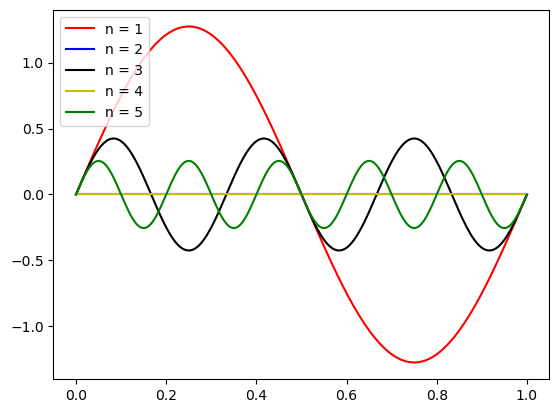

In [35]:
N_max = 5

colors = ['r', 'b', 'k', 'y', 'g', 'c', 'm']

def Fourier_comp(n, x, T):
    beta = [4/n/np.pi if n%2 == 1 else 0]
    return beta*np.sin(2*np.pi*n*x/T)

fig = plt.figure()
ax = fig.add_subplot(111)

for n in range(1,N_max+1):
    ax.plot(x_array, Fourier_comp(n, x_array, 1), label=f"n = {n}", color=colors[(n-1)%7])

ax.legend(loc='upper left')

plt.show()

We can add those components to see how they compare to $f(x)$.

$$
f(x) = f_1(x) + f_2(x) + f_3(x) + f_4(x) + \ldots
$$

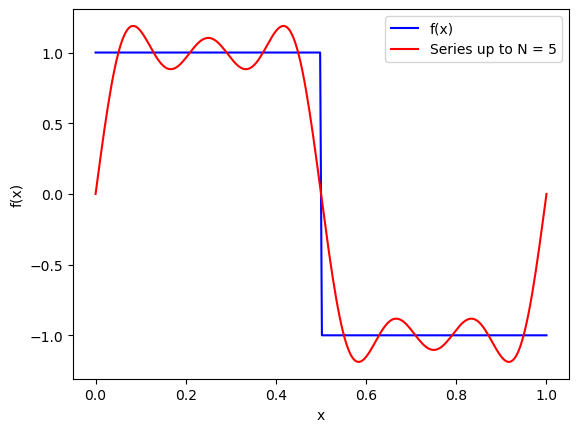

In [36]:
series = np.zeros(N)

for n in range(1, N_max+1):
    series += Fourier_comp(n, x_array, 1)

fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(x_array, fx, 'b', label="f(x)")
ax.plot(x_array, series, 'r', label=f"Series up to N = {N_max}")
ax.set_ylabel("f(x)")
ax.set_xlabel("x")

ax.legend(loc='upper right')


You can play with the value of $N\_max$. As it increases, the Fourier series above should become a better representation of the function $f(x)$. 

Fourier series assume that the function is periodic. In the example above, the period is one. If the function is periodic, then the Fourier series gives the right value everywhere. If it is not periodic, then the series the wrong value outside the region as shown below.

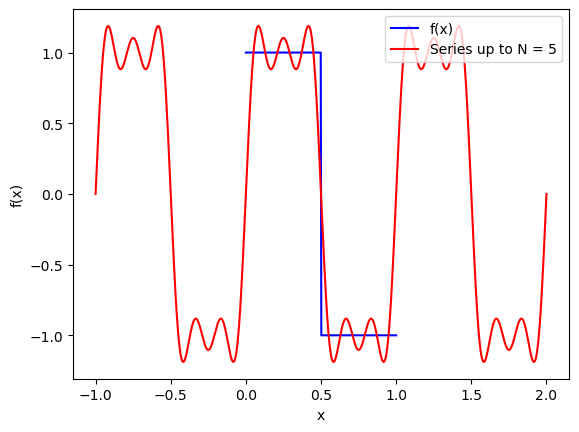

In [39]:
x_array_long = np.linspace(-1, 2, 3*N)

series = np.zeros(3*N)

for n in range(1, N_max+1):
    series += Fourier_comp(n, x_array_long, 1)

fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(x_array, fx, 'b', label="f(x)")
ax.plot(x_array_long, series, 'r', label=f"Series up to N = {N_max}")
ax.set_ylabel("f(x)")
ax.set_xlabel("x")

ax.legend(loc='upper right')

## Discrete Fourier transform

The DFT is a way to calculate the complex coefficient in the Fourier series that represent the function $f(x)$. It is expressed as:

$$
c_k = \sum_{n=0}^{N-1} y_n e^{-i2\pi kn/N}
$$

The inverse DFT (IDFT) computes the function $f(x)$ when we know the coefficients:

$$
y_n = \frac{1}{N} \sum_{k=0}^{N-1} c_k e^{i2\pi kn/N}
$$

The variable x is a placeholder. It can represent a spatial dimension of it can be replaced with time $t$. In this example, consider an electrical signal to some device that repeats every 1 second with a more complicated shape.

$$
f(t) = t\cos(8\pi t)
$$

for $0 \leq t \leq 1$. We show this function below: 

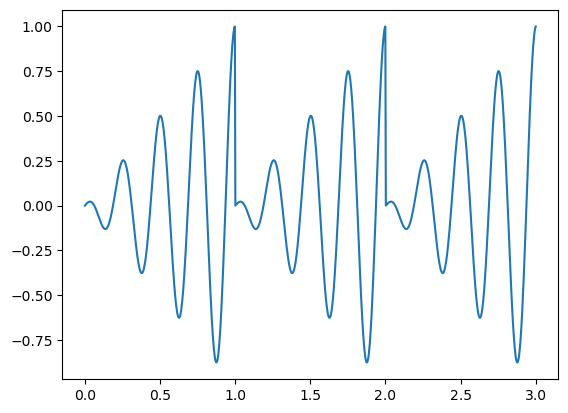

In [15]:
import numpy as np 
import matplotlib.pyplot as plt 

N_short = 300
N_long = 3*N_short
t_short = np.linspace(0, 1, N_short)
t_long = np.linspace(0, 3, N_long)

ft_short = t_short*np.cos(8*np.pi*t_short)

ft_long = np.append(ft_short, np.append(ft_short, ft_short))

fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(t_long, ft_long)

plt.show()


We can use the definition above to calculate the values of $c_k$. The $k$ array runs from 0 to $N-1$

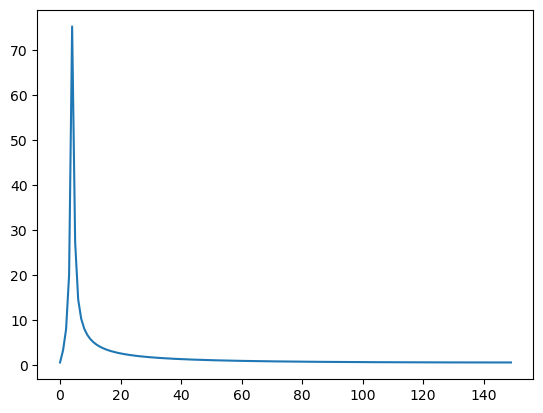

In [16]:
def ck(y, N):
    c = np.zeros(N, dtype='complex')
    for i in range(N):
        for j in range(N):
            c[i] += y[j]*np.exp(-1j*2*np.pi*i*j/N)
    return c

c = ck(ft_short, N_short)

fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(np.abs(c)[0:N_short//2]) # Truncate for only positive frequencies. Ignore for now.

plt.show()

We can use the IDFT to recover the original function.

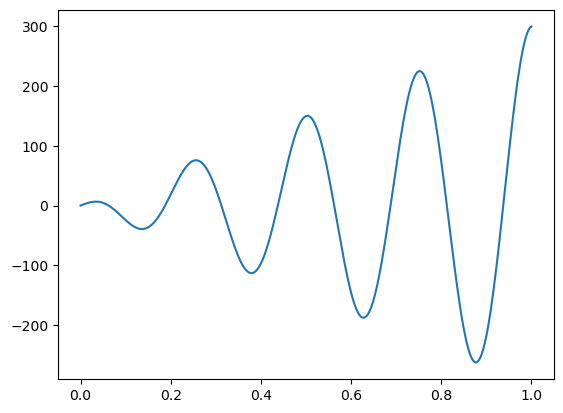

In [17]:
def yn(c, N):
    y = np.zeros(N_short, dtype='complex')
    for i in range(N_short):
        for j in range(N_short):
            y[i] += c[j]*np.exp(1j*2*np.pi*i*j/N)
    return y


y = yn(c, N_short)

fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(t_short, np.real(y)) 
plt.show()
